# Eval Plots — PlanningOrchestrator Benchmark
Laadt MLflow child-runs, groepeert per **agent group** (graph / salesforce / smartsales / orchestrator)
en toont scores, latency, tokens en rationale — vergelijkbaar met de Excel benchmark.

In [165]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('imports ok')
VERSION = "v4-graph-rag-finish" 

imports ok


In [166]:
# ── Config ────────────────────────────────────────────────────────────────────
TRACKING_URI = 'sqlite:///C:/Users/AALB/Desktop/mp/graph/graphxmaf/mlflow.db'
EXPERIMENT   = 'graphxmaf-eval'

# Category → agent group (zelfde indeling als Excel)
AGENT_GROUPS = {
    'graph':        ['email', 'calendar', 'files', 'people', 'identity'],
    'salesforce':   ['accounts', 'contacts', 'leads', 'opportunities', 'cases'],
    'smartsales':   ['locations', 'catalog', 'orders'],
    'orchestrator': ['cross-system'],
}

GROUP_ORDER  = ['graph', 'salesforce', 'smartsales', 'orchestrator']
GROUP_COLORS = {
    'graph':        '#3b82f6',
    'salesforce':   '#10b981',
    'smartsales':   '#f59e0b',
    'orchestrator': '#8b5cf6',
}

DIFFICULTY_ORDER = ['simple', 'medium', 'hard']
DIFF_COLORS      = {'simple': '#93c5fd', 'medium': '#3b82f6', 'hard': '#1e3a8a'}

# Geschatte GPT-4o prijs (USD per 1 000 tokens)
COST_IN_PER_1K  = 0.0025
COST_OUT_PER_1K = 0.010

In [167]:
# ── Data laden ────────────────────────────────────────────────────────────────
mlflow.set_tracking_uri(TRACKING_URI)
exp = mlflow.get_experiment_by_name(EXPERIMENT)
if exp is None:
    raise RuntimeError(f'Experiment "{EXPERIMENT}" niet gevonden. Eerst mlflow_eval.py runnen.')

raw = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string='tags.mlflow.parentRunId != ""',
    output_format='pandas',
)

RENAME = {
    'metrics.llm_score':          'llm_score',
    'metrics.routing_score':      'routing_score',
    'metrics.latency_s':          'latency_s',
    'metrics.total_tokens':       'total_tokens',
    'metrics.input_tokens':       'input_tokens',
    'metrics.output_tokens':      'output_tokens',
    'metrics.routing_precision':  'routing_precision',
    'metrics.routing_recall':     'routing_recall',
    'metrics.plan_steps':         'plan_steps',
    'metrics.parallel_ratio':     'parallel_ratio',
    'metrics.success':            'success',
    'tags.version':               'version',
    'tags.category':              'category',
    'tags.difficulty':            'difficulty',
    'tags.mlflow.runName':        'run_name',
    'tags.llm_rationale':         'llm_rationale',
    'tags.routing_rationale':     'routing_rationale',
    'tags.llm_comments':          'llm_comments',
    'params.query':               'query',
    'params.expected_agents':     'expected_agents',
}

df = raw.rename(columns={k: v for k, v in RENAME.items() if k in raw.columns})

CAT_TO_GROUP  = {cat: grp for grp, cats in AGENT_GROUPS.items() for cat in cats}
df['agent_group'] = df['category'].map(CAT_TO_GROUP).fillna('unknown')
df['difficulty']  = pd.Categorical(df['difficulty'], categories=DIFFICULTY_ORDER, ordered=True)

# Geschatte kost per run
df['cost_usd'] = (
    df.get('input_tokens',  pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_IN_PER_1K +
    df.get('output_tokens', pd.Series(0, index=df.index)).fillna(0) / 1000 * COST_OUT_PER_1K
)

VERSIONS   = sorted(df['version'].dropna().unique())
N_VERSIONS = len(VERSIONS)

print(f'Geladen   : {len(df)} child-runs')
print(f'Versies   : {VERSIONS}')
print(f'Groepen   : {df["agent_group"].value_counts().to_dict()}')
print(f'Succesvol : {df["success"].mean():.0%}  (n={int(df["success"].notna().sum())})')

Geladen   : 452 child-runs
Versies   : ['baseline', 'v1-planner-full', 'v1-planner-more-data', 'v1-simpler-planner-3', 'v1-simpler-planner-4', 'v1-simpler-planner-bottleneck', 'v2-tool-description', 'v3-prep-graphrag', 'v3-prep-graphrag-final', 'v3-prep-graphrag2', 'v3-prep-graphrag3', 'v4-graph-rag-finish', 'v4-graph-rag-first', 'v4-graph-rag-second']
Groepen   : {'salesforce': 128, 'unknown': 121, 'smartsales': 87, 'graph': 80, 'orchestrator': 36}
Succesvol : 100%  (n=444)


In [168]:
# # Neem alles van v3 BEHALVE salesforce, en vervang die door v4 salesforce
# BASE_VERSION     = 'v1-simpler-planner-3'
# OVERRIDE_VERSION = 'v1-simpler-planner-4'
# OVERRIDE_GROUP   = 'salesforce'

# df_raw      = df  # bewaar origineel zodat andere cellen baseline kunnen ophalen
# df_base     = df_raw[df_raw['version'] == BASE_VERSION]
# df_override = df_raw[(df_raw['version'] == OVERRIDE_VERSION) & (df_raw['agent_group'] == OVERRIDE_GROUP)]

# df_merged = pd.concat([
#     df_base[df_base['agent_group'] != OVERRIDE_GROUP],
#     df_override,
# ], ignore_index=True)
# df_merged['version'] = 'v3+v4-sf'

# print(f'Base ({BASE_VERSION}) non-salesforce : {len(df_base[df_base["agent_group"] != OVERRIDE_GROUP])} runs')
# print(f'Override ({OVERRIDE_VERSION}) salesforce   : {len(df_override)} runs')
# print(f'Merged totaal                    : {len(df_merged)} runs')
# print()
# print(df_merged.groupby('agent_group')[['llm_score', 'routing_score']].mean().round(2).reindex(GROUP_ORDER))


## 1. Samenvattingstabel per agent group

In [169]:
def _agg(g):
    return pd.Series({
        'N':               len(g),
        'LLM score':       round(g['llm_score'].mean(), 2),
        'Routing score':   round(g['routing_score'].mean(), 2),
        'Precision':       round(g['routing_precision'].mean(), 2),
        'Recall':          round(g['routing_recall'].mean(), 2),
        'Success':         round(g['success'].mean(), 2),
        'Latency avg (s)': round(g['latency_s'].mean(), 1),
        'Latency p95 (s)': round(g['latency_s'].quantile(0.95), 1),
        'Tokens avg':      int(g['total_tokens'].mean()) if g['total_tokens'].notna().any() else 0,
        'Cost avg (ct)':   round(g['cost_usd'].mean() * 100, 3),
    })

# ── Versiefilter ───────────────────────────────────────────────────────────────
# Laat leeg ([]) voor alle versies, of geef een subset op:
SHOW_VERSIONS = []

_versions = [v for v in SHOW_VERSIONS if v in df['version'].unique()] if SHOW_VERSIONS else VERSIONS
if unknown := set(SHOW_VERSIONS) - set(VERSIONS):
    print(f'⚠️  Niet gevonden: {sorted(unknown)}')

_df_sel = df[df['version'].isin(_versions)].copy()

# Onbekende groepen tonen op echte categorienaam i.p.v. 'unknown'
_df_sel['_group'] = _df_sel.apply(
    lambda r: r['agent_group'] if r['agent_group'] != 'unknown' else r['category'],
    axis=1,
)

summary = (
    _df_sel
    .groupby(['version', '_group'])
    .apply(_agg, include_groups=False)
    .reset_index()
    .rename(columns={'_group': 'agent_group'})
    .set_index(['version', 'agent_group'])
)

_extra_groups = sorted(g for g in _df_sel['_group'].unique() if g not in GROUP_ORDER)
_all_groups   = GROUP_ORDER + _extra_groups

idx = pd.MultiIndex.from_product([_versions, _all_groups], names=['version', 'agent_group'])
summary = summary.reindex(idx).dropna(how='all')

display(
    summary.style
    .format(precision=2)
    .background_gradient(subset=['LLM score', 'Routing score'], cmap='RdYlGn', vmin=1, vmax=5)
    .background_gradient(subset=['Precision', 'Recall', 'Success'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption(f'Gemiddelden per versie × agent group  [{", ".join(_versions)}]')
)

## 2. LLM Score & Routing Score per agent group

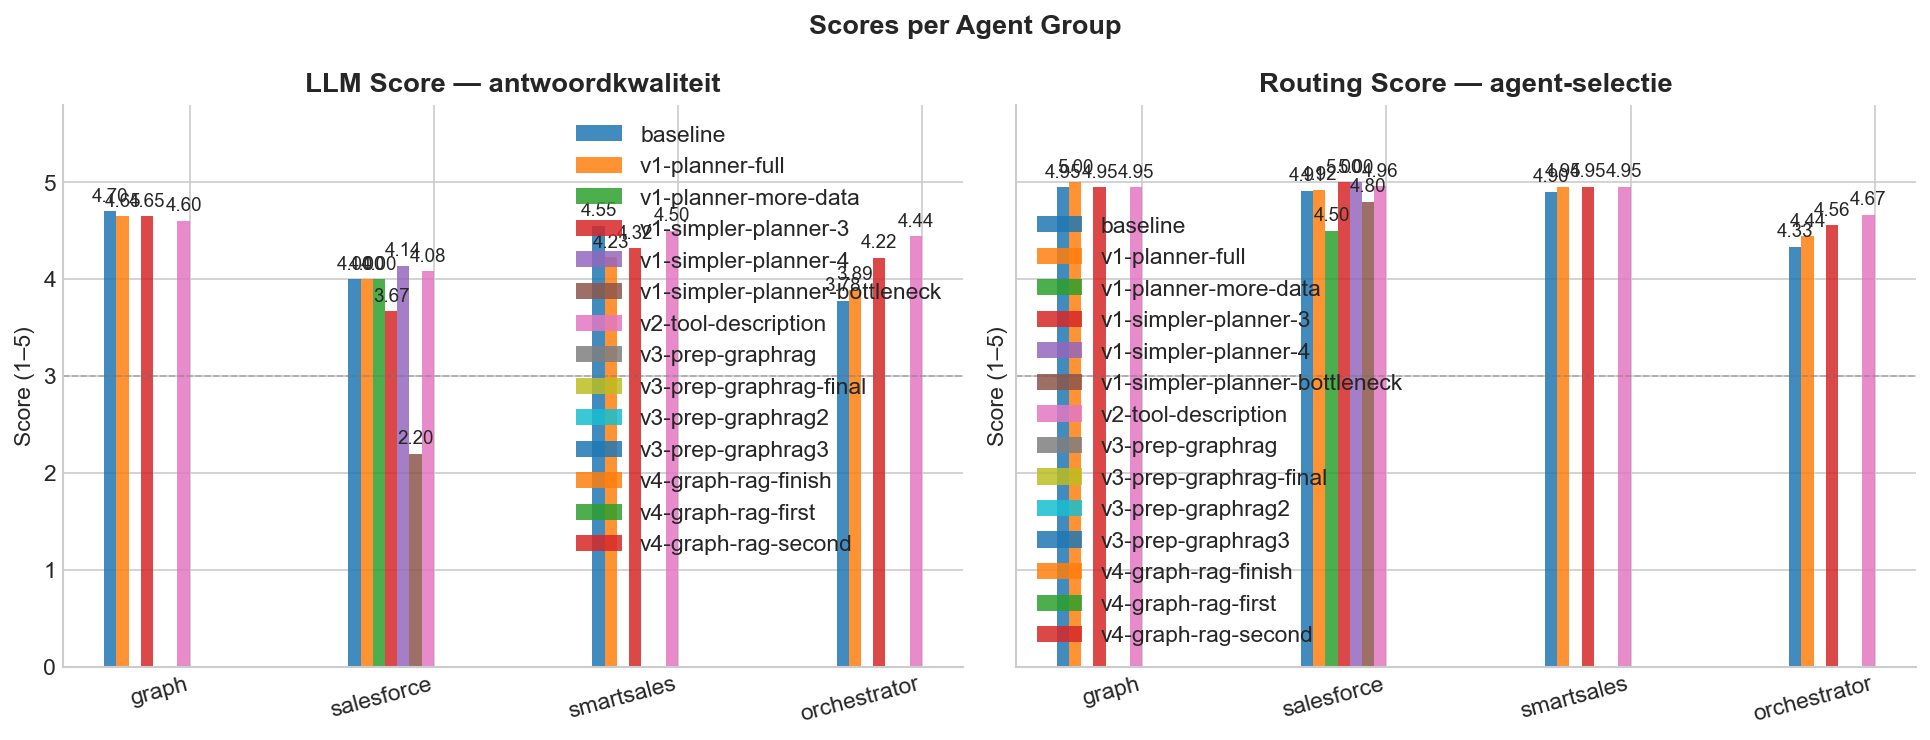

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score — antwoordkwaliteit'),
    ('routing_score', 'Routing Score — agent-selectie'),
]):
    ax  = axes[ax_idx]
    x   = np.arange(len(GROUP_ORDER))
    bar_w = 0.7 / max(N_VERSIONS, 1)

    for v_idx, version in enumerate(VERSIONS):
        vdf  = df[df['version'] == version]
        vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
        off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
        bars = ax.bar(
            x + off, vals, bar_w,
            label=version,
            color=[GROUP_COLORS[g] for g in GROUP_ORDER] if N_VERSIONS == 1 else None,
            alpha=0.85,
        )
        for bar, val in zip(bars, vals):
            if not (val != val):  # not NaN
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.06,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    if N_VERSIONS > 1:
        ax.legend()

plt.suptitle('Scores per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_group.png', bbox_inches='tight')
plt.show()

## 3. Score per categorie (binnen elke agent group)

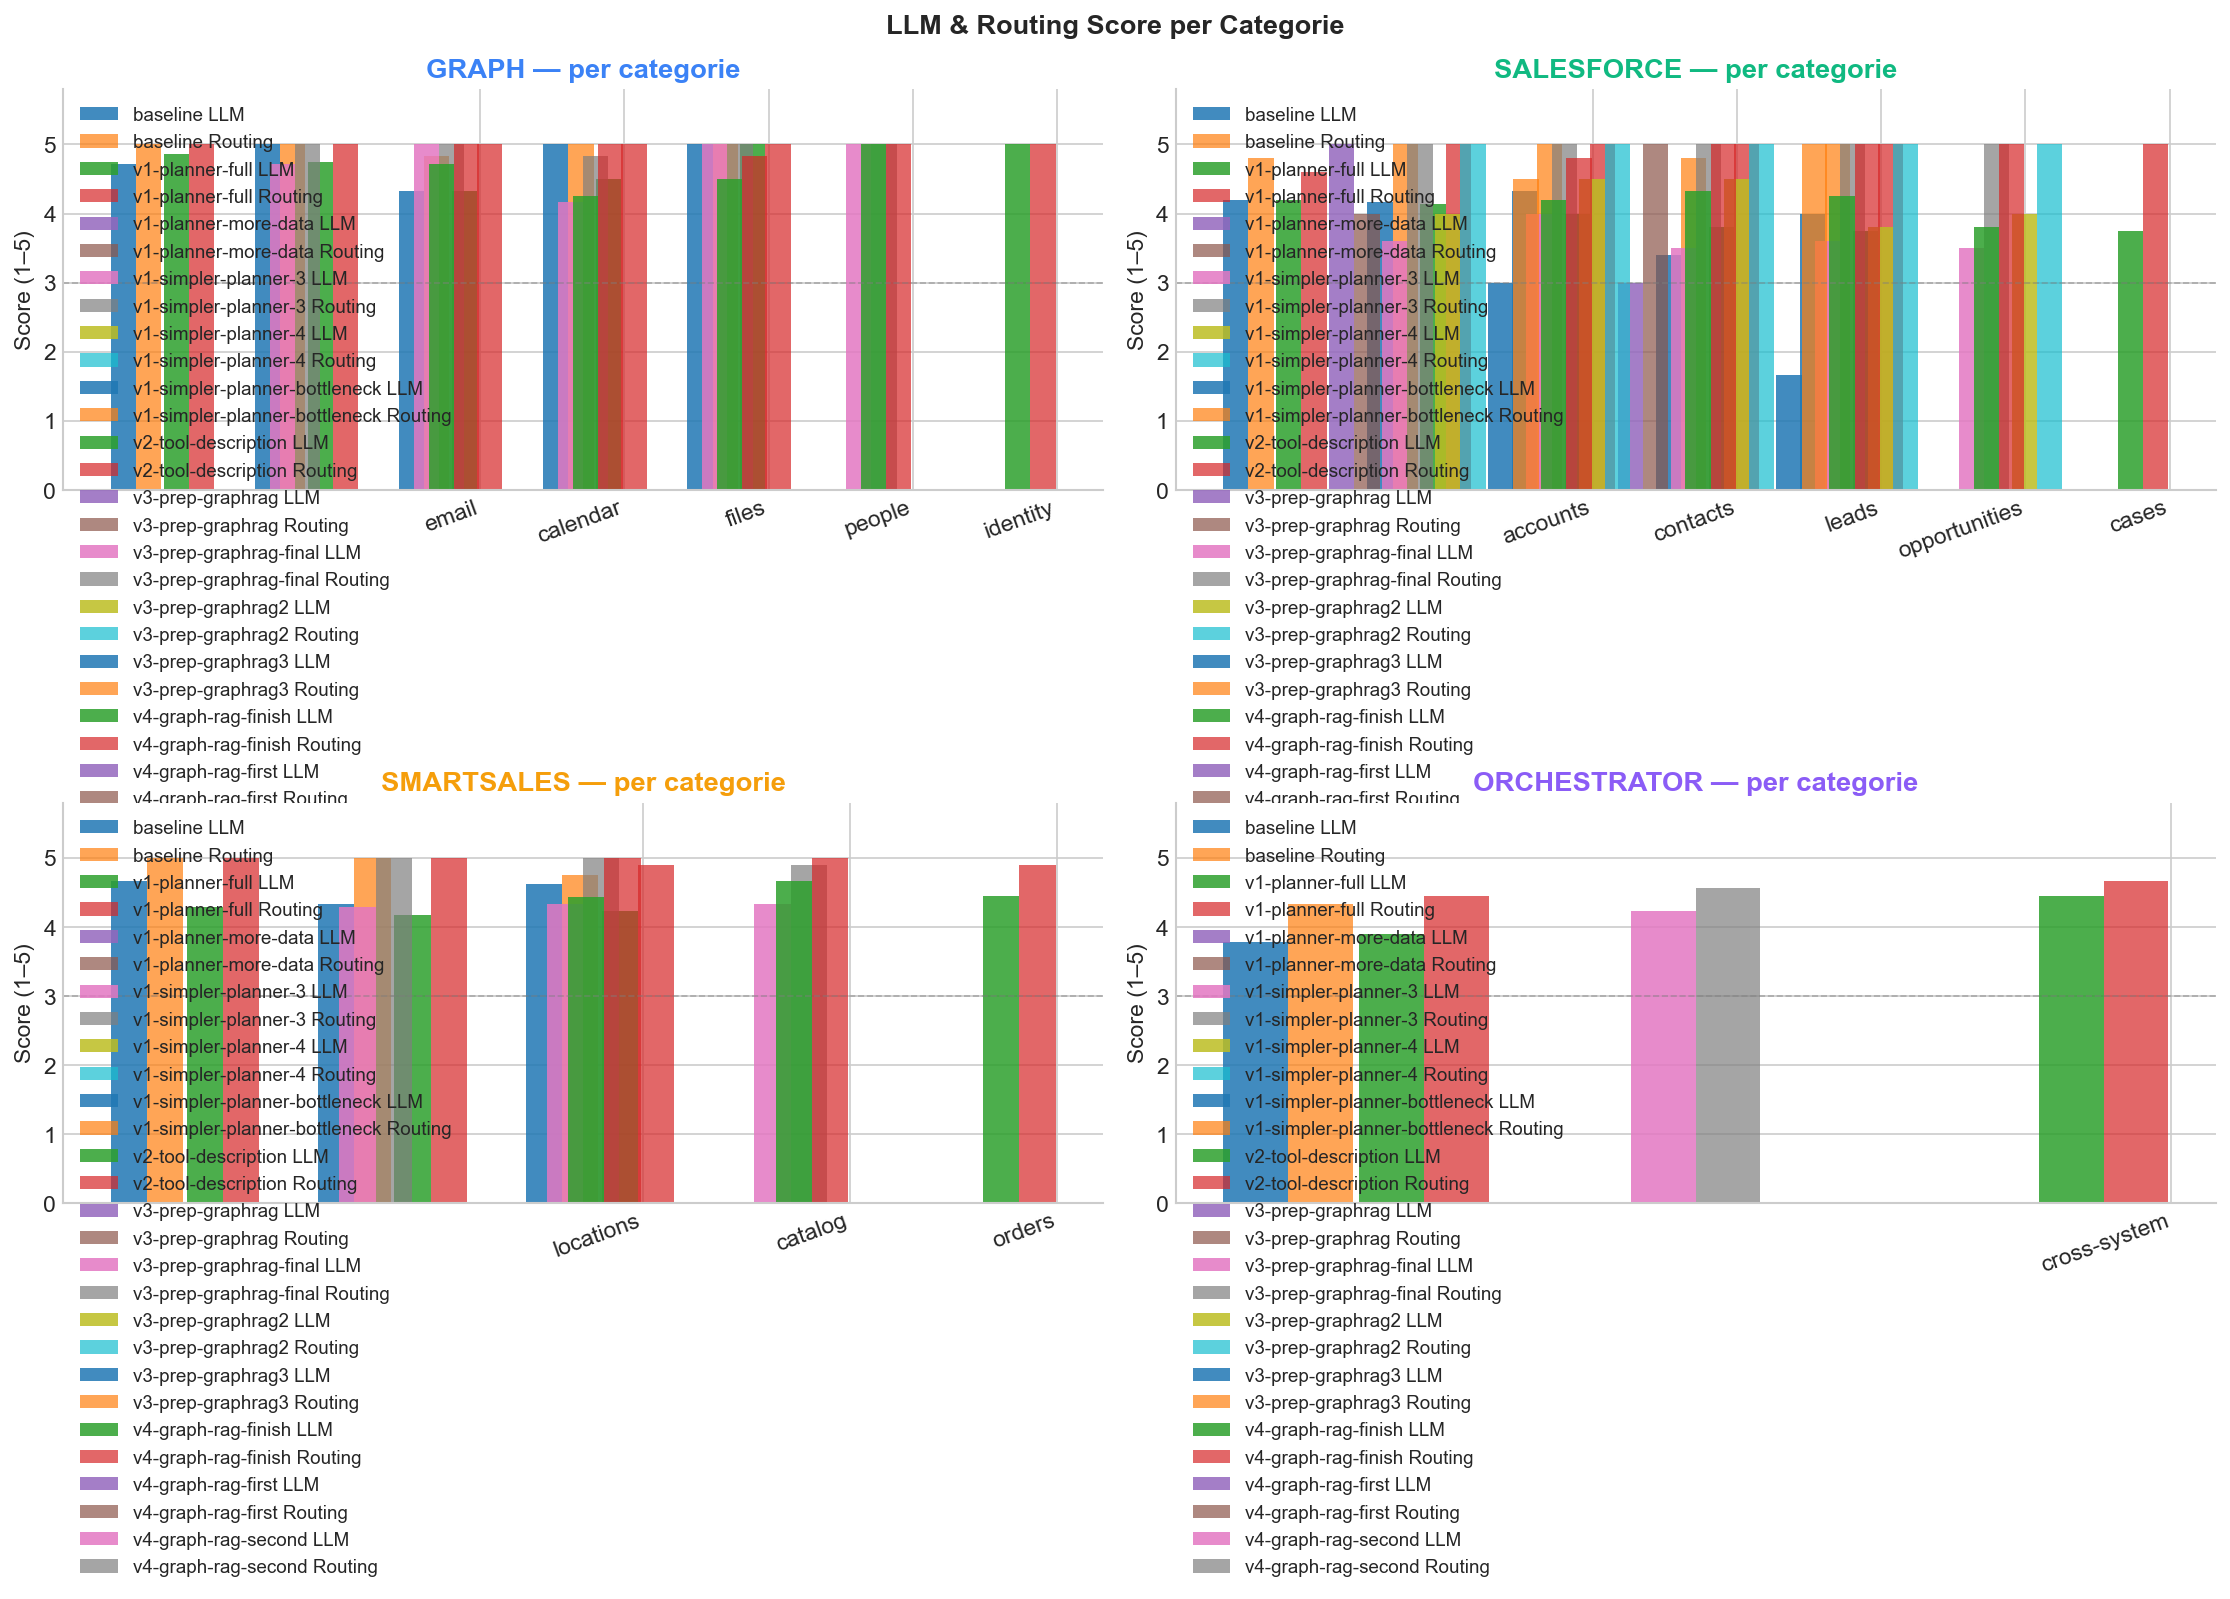

In [171]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, group in enumerate(GROUP_ORDER):
    ax   = axes[ax_idx]
    cats = AGENT_GROUPS[group]
    gdf  = df[df['agent_group'] == group]
    x    = np.arange(len(cats))
    w    = 0.35

    if N_VERSIONS == 1:
        version = VERSIONS[0]
        vdf = gdf[gdf['version'] == version]
        llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
        rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
        ax.bar(x - w/2, llm_vals,  w, label='LLM score',    color='#3b82f6', alpha=0.85)
        ax.bar(x + w/2, rout_vals, w, label='Routing score', color='#10b981', alpha=0.85)
    else:
        for v_idx, version in enumerate(VERSIONS):
            vdf = gdf[gdf['version'] == version]
            llm_vals  = [vdf[vdf['category'] == c]['llm_score'].mean() for c in cats]
            rout_vals = [vdf[vdf['category'] == c]['routing_score'].mean() for c in cats]
            off = (v_idx - (N_VERSIONS - 1) / 2) * w * 1.05
            ax.bar(x + off - w/4, llm_vals,  w/2, label=f'{version} LLM',     alpha=0.85)
            ax.bar(x + off + w/4, rout_vals, w/2, label=f'{version} Routing', alpha=0.70)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(f'{group.upper()} — per categorie', fontweight='bold',
                 color=GROUP_COLORS[group])
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('LLM & Routing Score per Categorie', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_per_category.png', bbox_inches='tight')
plt.show()

## 4. Score per moeilijkheidsgraad

C:\Users\AALB\AppData\Local\Temp\ipykernel_3688\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]
C:\Users\AALB\AppData\Local\Temp\ipykernel_3688\2040873186.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['agent_group', 'difficulty'])[metric]


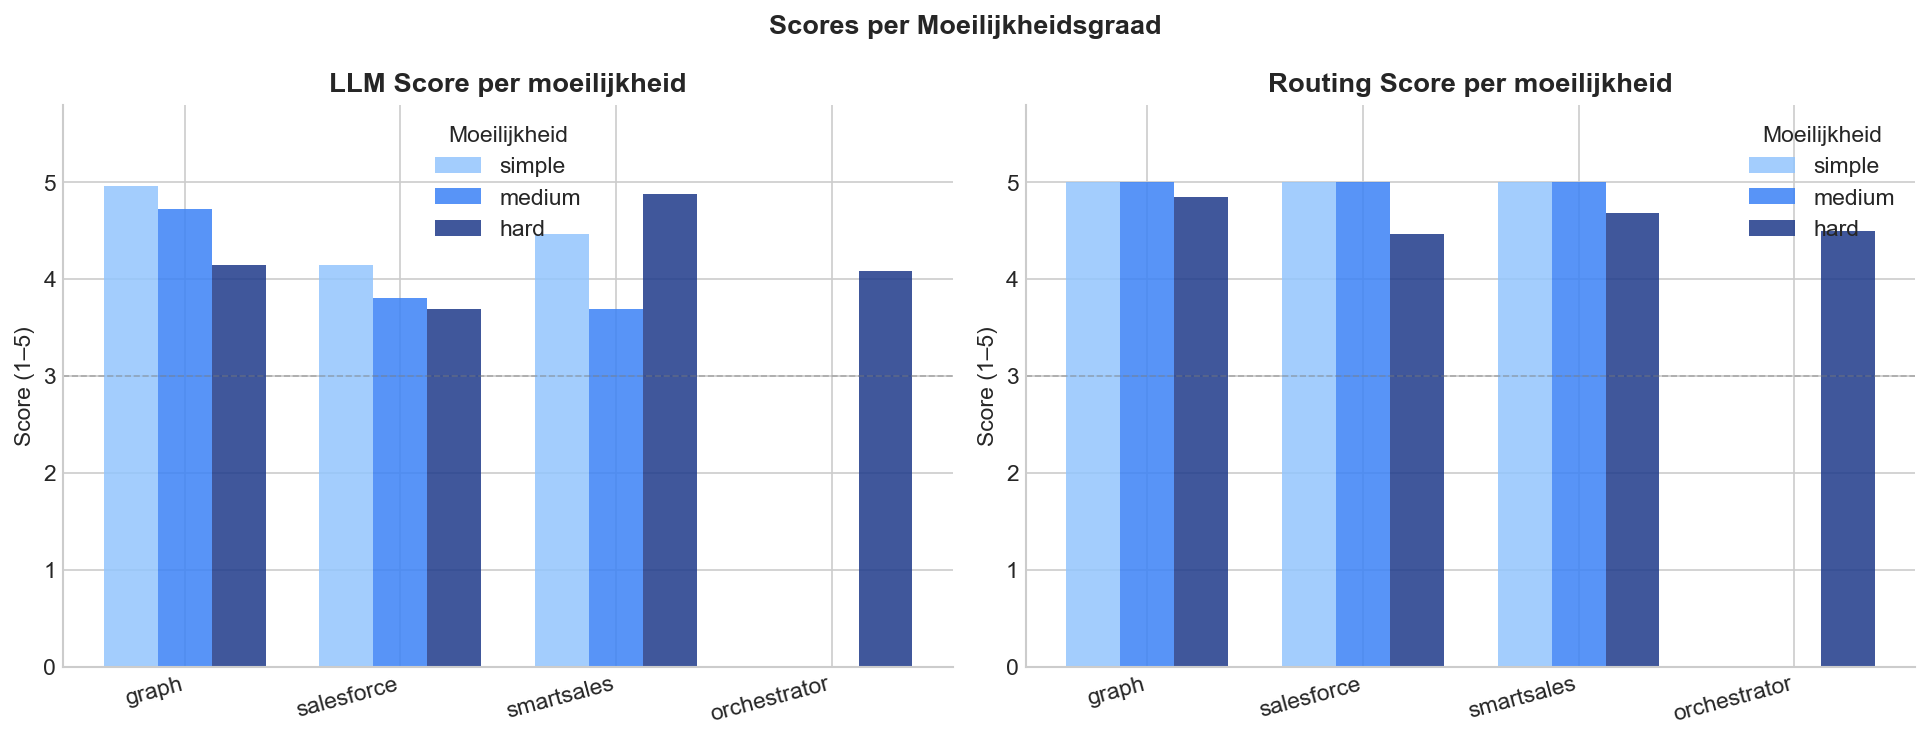

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (metric, title) in enumerate([
    ('llm_score',     'LLM Score per moeilijkheid'),
    ('routing_score', 'Routing Score per moeilijkheid'),
]):
    ax = axes[ax_idx]
    pivot = (
        df.groupby(['agent_group', 'difficulty'])[metric]
        .mean()
        .unstack('difficulty')
        .reindex(GROUP_ORDER)
        .reindex(columns=DIFFICULTY_ORDER)
    )
    x = np.arange(len(GROUP_ORDER))
    w = 0.25
    for d_idx, diff in enumerate(DIFFICULTY_ORDER):
        vals = pivot[diff].values if diff in pivot.columns else [np.nan] * len(GROUP_ORDER)
        off  = (d_idx - 1) * w
        ax.bar(x + off, vals, w, label=diff, color=DIFF_COLORS[diff], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
    ax.set_ylim(0, 5.8)
    ax.set_ylabel('Score (1–5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(3, ls='--', color='gray', lw=0.8, alpha=0.5)
    ax.legend(title='Moeilijkheid')

plt.suptitle('Scores per Moeilijkheidsgraad', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_scores_by_difficulty.png', bbox_inches='tight')
plt.show()

## 5. Latency per agent group

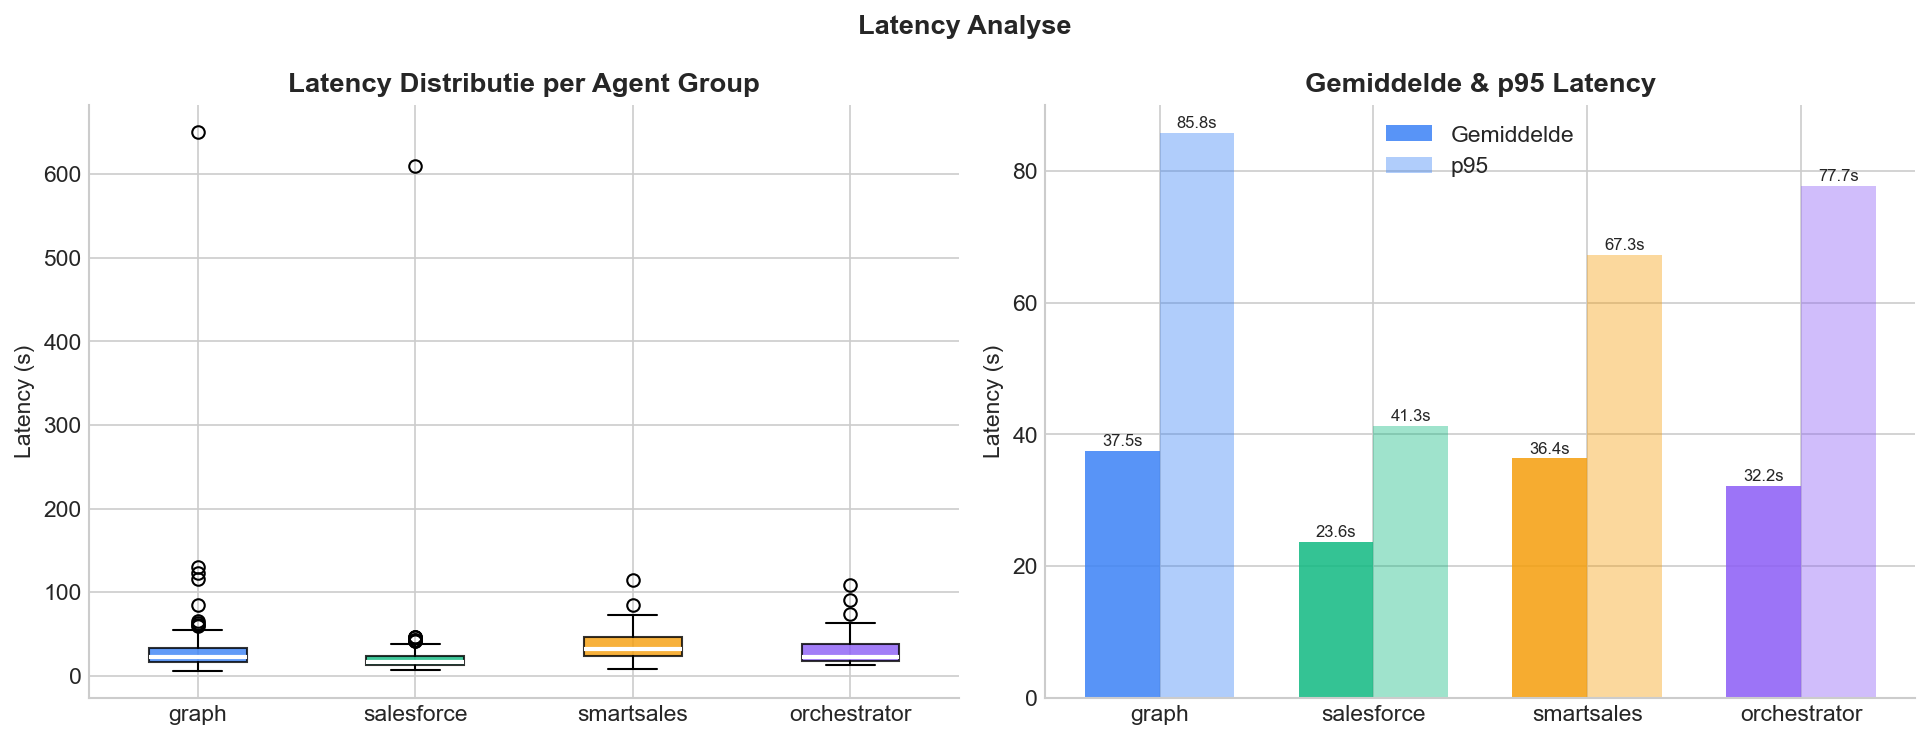

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
ax = axes[0]
box_data = [df[df['agent_group'] == g]['latency_s'].dropna().values for g in GROUP_ORDER]
bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, grp in zip(bp['boxes'], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[grp])
    patch.set_alpha(0.8)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Latency Distributie per Agent Group', fontweight='bold')

# Gemiddelde + p95
ax = axes[1]
x     = np.arange(len(GROUP_ORDER))
w     = 0.35
means = [df[df['agent_group'] == g]['latency_s'].mean() for g in GROUP_ORDER]
p95s  = [df[df['agent_group'] == g]['latency_s'].quantile(0.95) for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, means, w, label='Gemiddelde',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
b2 = ax.bar(x + w/2, p95s,  w, label='p95',
            color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.4)

for bar, val in zip(list(b1) + list(b2), means + p95s):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Latency (s)')
ax.set_title('Gemiddelde & p95 Latency', fontweight='bold')
ax.legend()

plt.suptitle('Latency Analyse', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_latency.png', bbox_inches='tight')
plt.show()

## 6. Token gebruik & geschatte kost

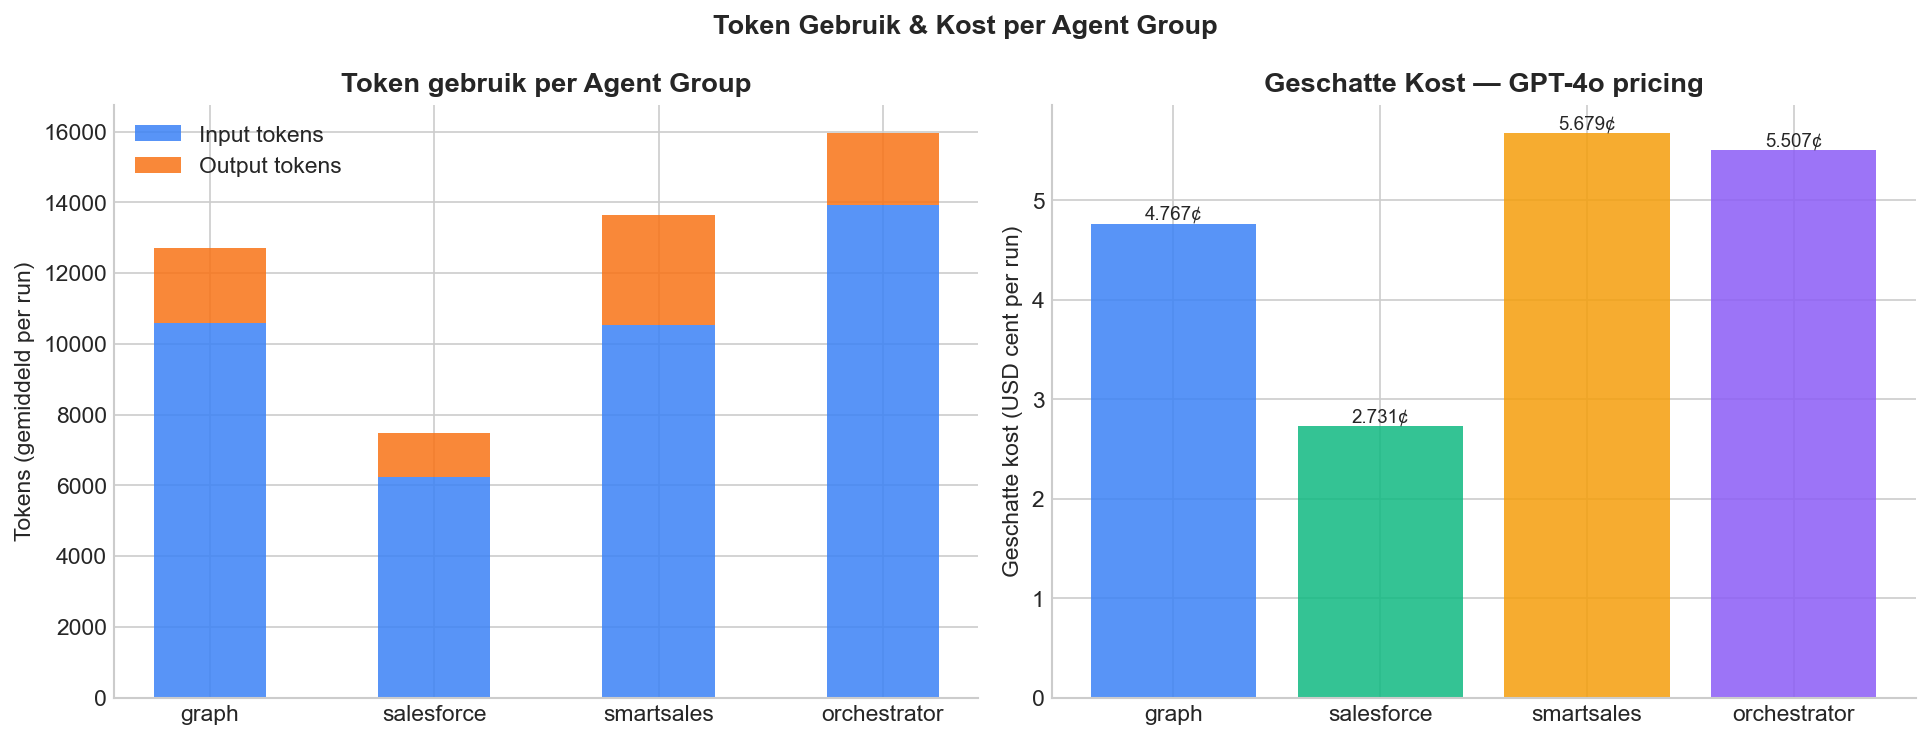

Totale geschatte kost voor deze run(s): $20.8136 USD (2081.36 cent)


In [174]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tokens (stacked)
ax = axes[0]
x       = np.arange(len(GROUP_ORDER))
in_tok  = [df[df['agent_group'] == g]['input_tokens'].mean() for g in GROUP_ORDER]
out_tok = [df[df['agent_group'] == g]['output_tokens'].mean() for g in GROUP_ORDER]
ax.bar(x, in_tok,  0.5, label='Input tokens',  color='#3b82f6', alpha=0.85)
ax.bar(x, out_tok, 0.5, bottom=in_tok, label='Output tokens', color='#f97316', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Tokens (gemiddeld per run)')
ax.set_title('Token gebruik per Agent Group', fontweight='bold')
ax.legend()

# Kost (USD cent)
ax = axes[1]
costs = [df[df['agent_group'] == g]['cost_usd'].mean() * 100 for g in GROUP_ORDER]
bars  = ax.bar(x, costs, color=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
for bar, val in zip(bars, costs):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{val:.3f}¢', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylabel('Geschatte kost (USD cent per run)')
ax.set_title('Geschatte Kost — GPT-4o pricing', fontweight='bold')

plt.suptitle('Token Gebruik & Kost per Agent Group', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_tokens_cost.png', bbox_inches='tight')
plt.show()

total_cost = df['cost_usd'].sum()
print(f'Totale geschatte kost voor deze run(s): ${total_cost:.4f} USD ({total_cost*100:.2f} cent)')

## 7. Routing Precision & Recall per agent group

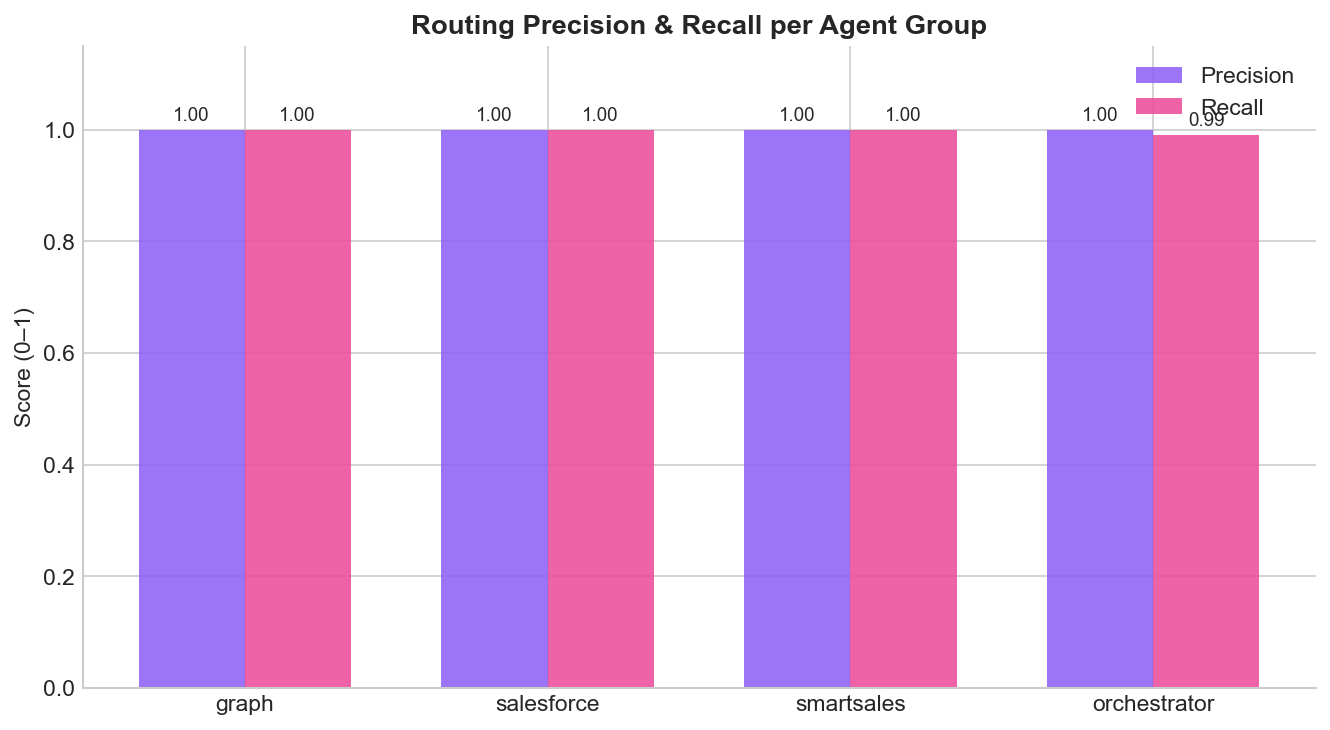

In [175]:
fig, ax = plt.subplots(figsize=(9, 5))
x    = np.arange(len(GROUP_ORDER))
w    = 0.35
prec = [df[df['agent_group'] == g]['routing_precision'].mean() for g in GROUP_ORDER]
rec  = [df[df['agent_group'] == g]['routing_recall'].mean() for g in GROUP_ORDER]

b1 = ax.bar(x - w/2, prec, w, label='Precision', color='#8b5cf6', alpha=0.85)
b2 = ax.bar(x + w/2, rec,  w, label='Recall',    color='#ec4899', alpha=0.85)

for bar, val in zip(list(b1) + list(b2), prec + rec):
    if not (val != val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (0–1)')
ax.set_title('Routing Precision & Recall per Agent Group', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_routing_precision_recall.png', bbox_inches='tight')
plt.show()

## 8. Slechtst scorende cases + rationale

In [185]:
LOW_THRESHOLD = 3  # pas aan om meer/minder cases te zien
# VERSION = 'v1-simpler-planner-4'
VERSION = "v4-graph-rag-finish"

_client = mlflow.MlflowClient()

def _load_response(run_id: str, max_chars: int = 500) -> str:
    """Laad response.txt artifact voor een run."""
    try:
        for art in _client.list_artifacts(run_id):
            if art.path.endswith("_response.txt"):
                local = _client.download_artifacts(run_id, art.path)
                with open(local, encoding="utf-8") as f:
                    text = f.read().strip()
                return text[:max_chars] + ("…" if len(text) > max_chars else "")
    except Exception as e:
        return f"[error: {e}]"
    return "[geen response artifact]"

low = (
    df[(df['llm_score'] <= LOW_THRESHOLD) & (df['version'] == VERSION)]
    .sort_values(['agent_group', 'llm_score', 'difficulty'])
    .assign(run_id_short=lambda d: d['run_id'].str[:8])
    .reset_index(drop=True)
)

low['response'] = low['run_id'].apply(_load_response)

low = low[['run_name', 'run_id_short', 'version', 'agent_group', 'category', 'difficulty',
           'llm_score', 'routing_score', 'query', 'response', 'llm_rationale']]

print(f'Cases met llm_score <= {LOW_THRESHOLD}: {len(low)} / {len(df)}')

pd.set_option('display.max_colwidth', 300)
pd.set_option('display.max_rows', 60)

display(
    low.style
    .map(
        lambda v: 'background-color:#fee2e2' if v == 1 else
                  ('background-color:#fef9c3' if v == 2 else ''),
        subset=['llm_score', 'routing_score'],
    )
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_caption(f'Lage-score cases (llm_score <= {LOW_THRESHOLD})')
)

# ── Volledige run_ids afdrukken ───────────────────────────────────────────────
full_ids = (
    df[(df['llm_score'] <= LOW_THRESHOLD) & (df['version'] == VERSION)]
    .sort_values(['agent_group', 'llm_score'])
    [['run_name', 'run_id']]
    .reset_index(drop=True)
)

print('\n── Run IDs ──')
for _, row in full_ids.iterrows():
    name = row.get('run_name') or '?'
    print(f"  {name:<35}  {row['run_id']}")

Cases met llm_score <= 3: 5 / 452


,run_name,run_id_short,version,agent_group,category,difficulty,llm_score,routing_score,query,response,llm_rationale
0,tc04_onedrive-rag_simple,abdcda92,v4-graph-rag-finish,unknown,onedrive-rag,simple,3.000000,5.000000,How much advance notice does supplier1 need to give before a scheduled maintenance visit?,Planning query... Plan: 1 stap(pen) ️Executing (graph)... Synthesizing... - From maintenance_contract_supplier1: Supplier1 needs to give at least 4 weeks advance notice before a scheduled maintenance visit by confirming the dates and technician assignment via email to procurement@easi.net.,"The response correctly states the need for 4 weeks advance notice and the contact email, but it fails to mention the preventive maintenance schedule, which is a significant omission."
1,tc03_onedrive-rag_simple,4a177893,v4-graph-rag-finish,unknown,onedrive-rag,simple,3.000000,5.000000,When does my health insurance start as a new EASI employee?,Planning query... Plan: 1 stap(pen) ️Executing (graph)... Synthesizing... From the graph: - New EASI employees' health insurance (hospitalization plan) starts after completing **3 months of service** with the company.,"The response correctly states that health insurance starts after 3 months of service, but it lacks details about the DKV Belgium policy, coverage specifics, optional modules, and the consequences of missing the waiting period."
2,tc11_onedrive-rag_medium,c1a6b6b6,v4-graph-rag-finish,unknown,onedrive-rag,medium,3.000000,5.000000,I want to work remotely from Spain for 3 weeks. Is this allowed under EASI policy?,"Planning query... Plan: 1 stap(pen) ️Executing (graph)... Synthesizing... To address your query regarding remote work from Spain under the EASI policy, here are the key points: - **General Policy**: Working from a country other than Belgium is not part of the standard remote work arrangement and requires explicit prior approval from HR. - **Approval Factors**: The approval process considers: - Tax residency - Social security implications - Duration of the stay - Local regulatory environ…","The response correctly identifies that working from Spain requires HR approval and mentions the 10-day limit for short stays, but it fails to explicitly state that 15 working days exceeds this limit, which is a significant oversight."
3,tc10_onedrive-rag_medium,0607bac6,v4-graph-rag-finish,unknown,onedrive-rag,medium,3.000000,5.000000,How do I report a suspected phishing email and what are the consequences if I fail a phishing test twice?,"Planning query... Plan: 1 stap(pen) ️Executing (graph)... Synthesizing... Here’s how to report a suspected phishing email and the consequences of failing a phishing test: ### Reporting a Suspected Phishing Email - **Method**: Use the ""Report Phishing"" button in Outlook for suspected phishing attempts received in EASI mailboxes. - **Alternative**: If the button is not available, send an email to security@easi.net. - **Review Time**: The IT security team will review each report within 4 working h…","The response provides a method for reporting phishing emails and mentions HR involvement for failing a phishing test, but it misses key details such as the specific reporting email and portal, the quarterly frequency of tests, and the explicit mentio"
4,tc12_onedrive-rag_hard,56eed0c6,v4-graph-rag-finish,unknown,onedrive-rag,hard,3.000000,5.000000,We discovered a data breach involving Colruyt customer data at 10:00 AM. What are all the notification steps and deadlines?,"Planning query... Plan: 1 stap(pen) ️Executing (graph)... Synthesizing... Here is a summary of the notification steps and deadlines following the discovery of a data breach involving Colruyt customer data: 1. **Internal Reporting**: - EASI employees must report the breach within **2 hours** to the EASI Data Protection Officer (DPO) via privacy@easi.net or dpo@easi.net. 2. **Notification to Clients**: - EASI must notify affected clients within **24 hours** of identifying the breach, regar…","The re


── Run IDs ──
  tc12_onedrive-rag_hard               56eed0c6aafd43879e0229fffc2fd6c6
  tc11_onedrive-rag_medium             c1a6b6b6902b4caa87ce79460d185d71
  tc10_onedrive-rag_medium             0607bac6b7ab4c0ea2be825d24f7ca99
  tc04_onedrive-rag_simple             abdcda9283714ee586faed634284038b
  tc03_onedrive-rag_simple             4a1778935ff2468b9eeeab5cd3307e09


In [177]:
for run_id in [

"318ff439b05943758f1054d7157a6cb3",
# "63b92ba6e4654b7cb730f3a45b2a4dad",



]:
    mlflow.delete_run(run_id)

## 9. Cross-system / Orchestrator deep dive

Cross-system cases: 36


,version,difficulty,llm_score,routing_score,plan_steps,parallel_ratio,latency_s,total_tokens
0,v1-planner-full,hard,3.0,5.0,2.0,0.500,20.654,12421.0
1,v1-planner-full,hard,3.0,3.0,2.0,0.500,63.565,20690.0
2,v1-planner-full,hard,3.0,5.0,3.0,0.333,25.266,26635.0
3,baseline,hard,3.0,4.0,2.0,0.500,19.750,10066.0
4,baseline,hard,3.0,5.0,3.0,1.000,13.920,10338.0
5,baseline,hard,3.0,5.0,2.0,0.500,18.690,6681.0
6,v2-tool-description,hard,4.0,4.0,3.0,0.667,42.729,26264.0
7,v2-tool-description,hard,4.0,5.0,3.0,0.333,34.940,34781.0
8,v1-planner-full,hard,4.0,5.0,2.0,0.500,17.491,10332.0
9,v1-planner-full,hard,4.0,4.0,2.0,1.000,12.272,6586.0


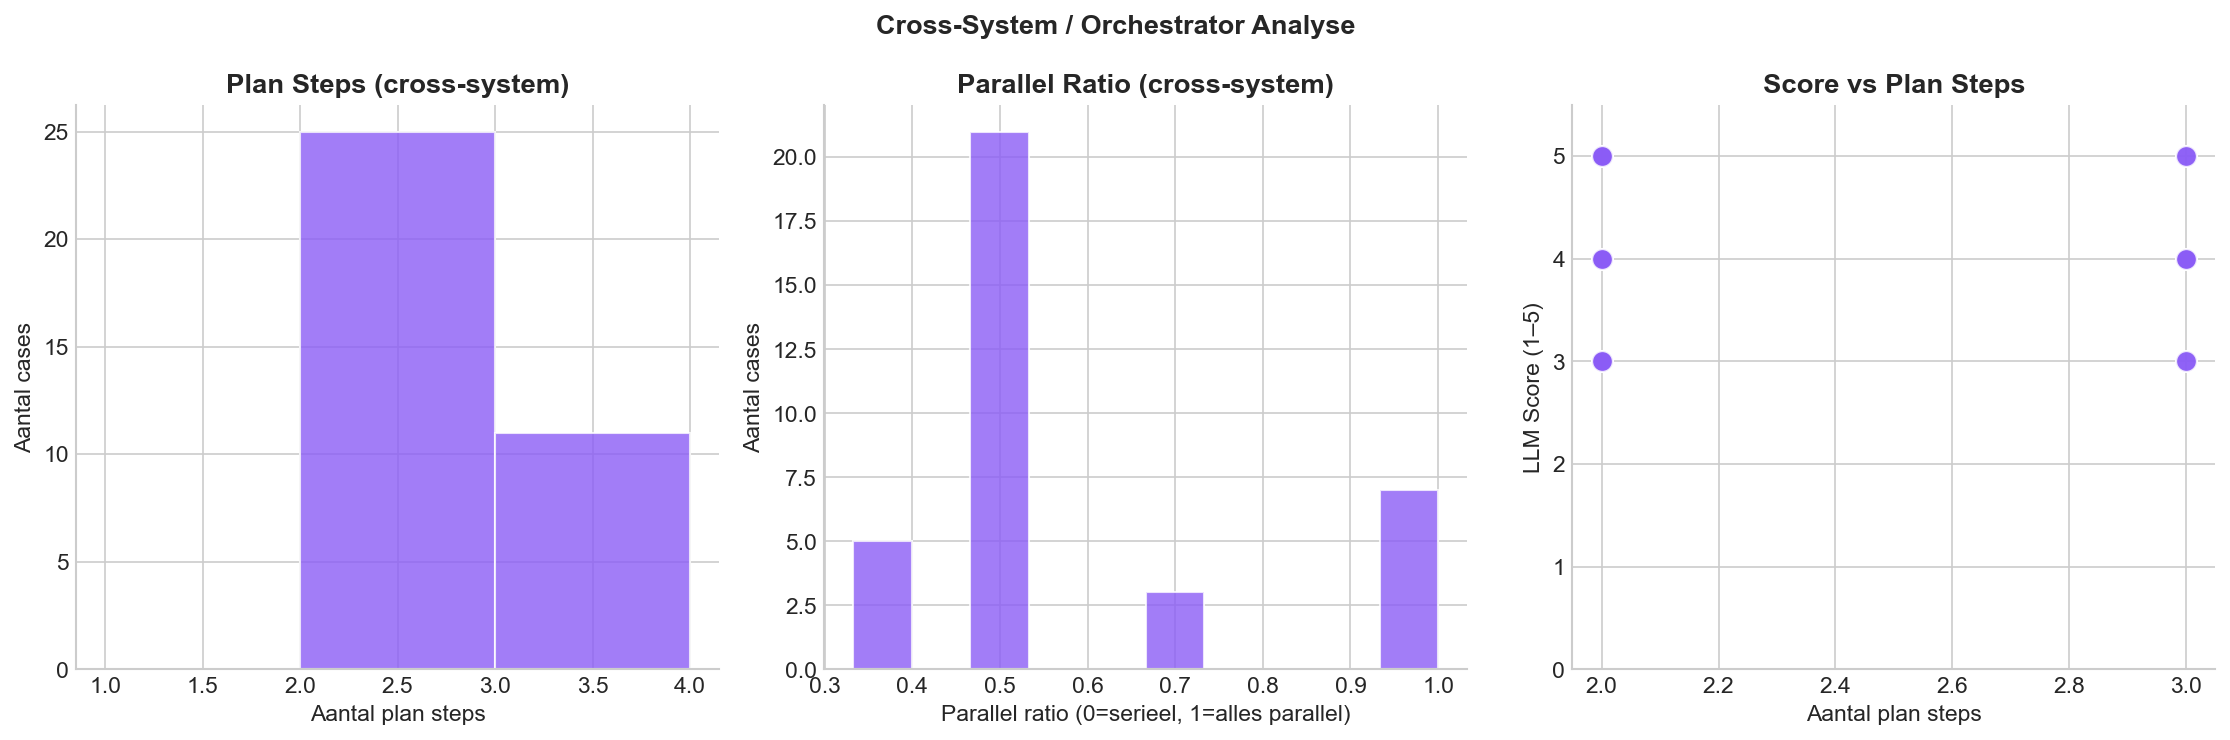

In [178]:
cross = df[df['agent_group'] == 'orchestrator'].copy()
print(f'Cross-system cases: {len(cross)}')
display(cross[['version', 'difficulty', 'llm_score', 'routing_score',
               'plan_steps', 'parallel_ratio', 'latency_s', 'total_tokens']]
        .sort_values('llm_score').reset_index(drop=True))

if len(cross) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Verdeling plan steps
    ax = axes[0]
    bins = range(1, int(cross['plan_steps'].max() + 2)) if cross['plan_steps'].notna().any() else range(1, 6)
    ax.hist(cross['plan_steps'].dropna(), bins=bins, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Plan Steps (cross-system)', fontweight='bold')

    # Parallel ratio
    ax = axes[1]
    ax.hist(cross['parallel_ratio'].dropna(), bins=10, color='#8b5cf6', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Parallel ratio (0=serieel, 1=alles parallel)')
    ax.set_ylabel('Aantal cases')
    ax.set_title('Parallel Ratio (cross-system)', fontweight='bold')

    # Score vs plan steps scatter
    ax = axes[2]
    ax.scatter(cross['plan_steps'], cross['llm_score'],
               c='#8b5cf6', s=100, alpha=0.8, edgecolors='white', zorder=3)
    ax.set_xlabel('Aantal plan steps')
    ax.set_ylabel('LLM Score (1–5)')
    ax.set_ylim(0, 5.5)
    ax.set_title('Score vs Plan Steps', fontweight='bold')

    plt.suptitle('Cross-System / Orchestrator Analyse', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('plot_cross_system.png', bbox_inches='tight')
    plt.show()

## 10. Versievergelijking (baseline vs v1 …)

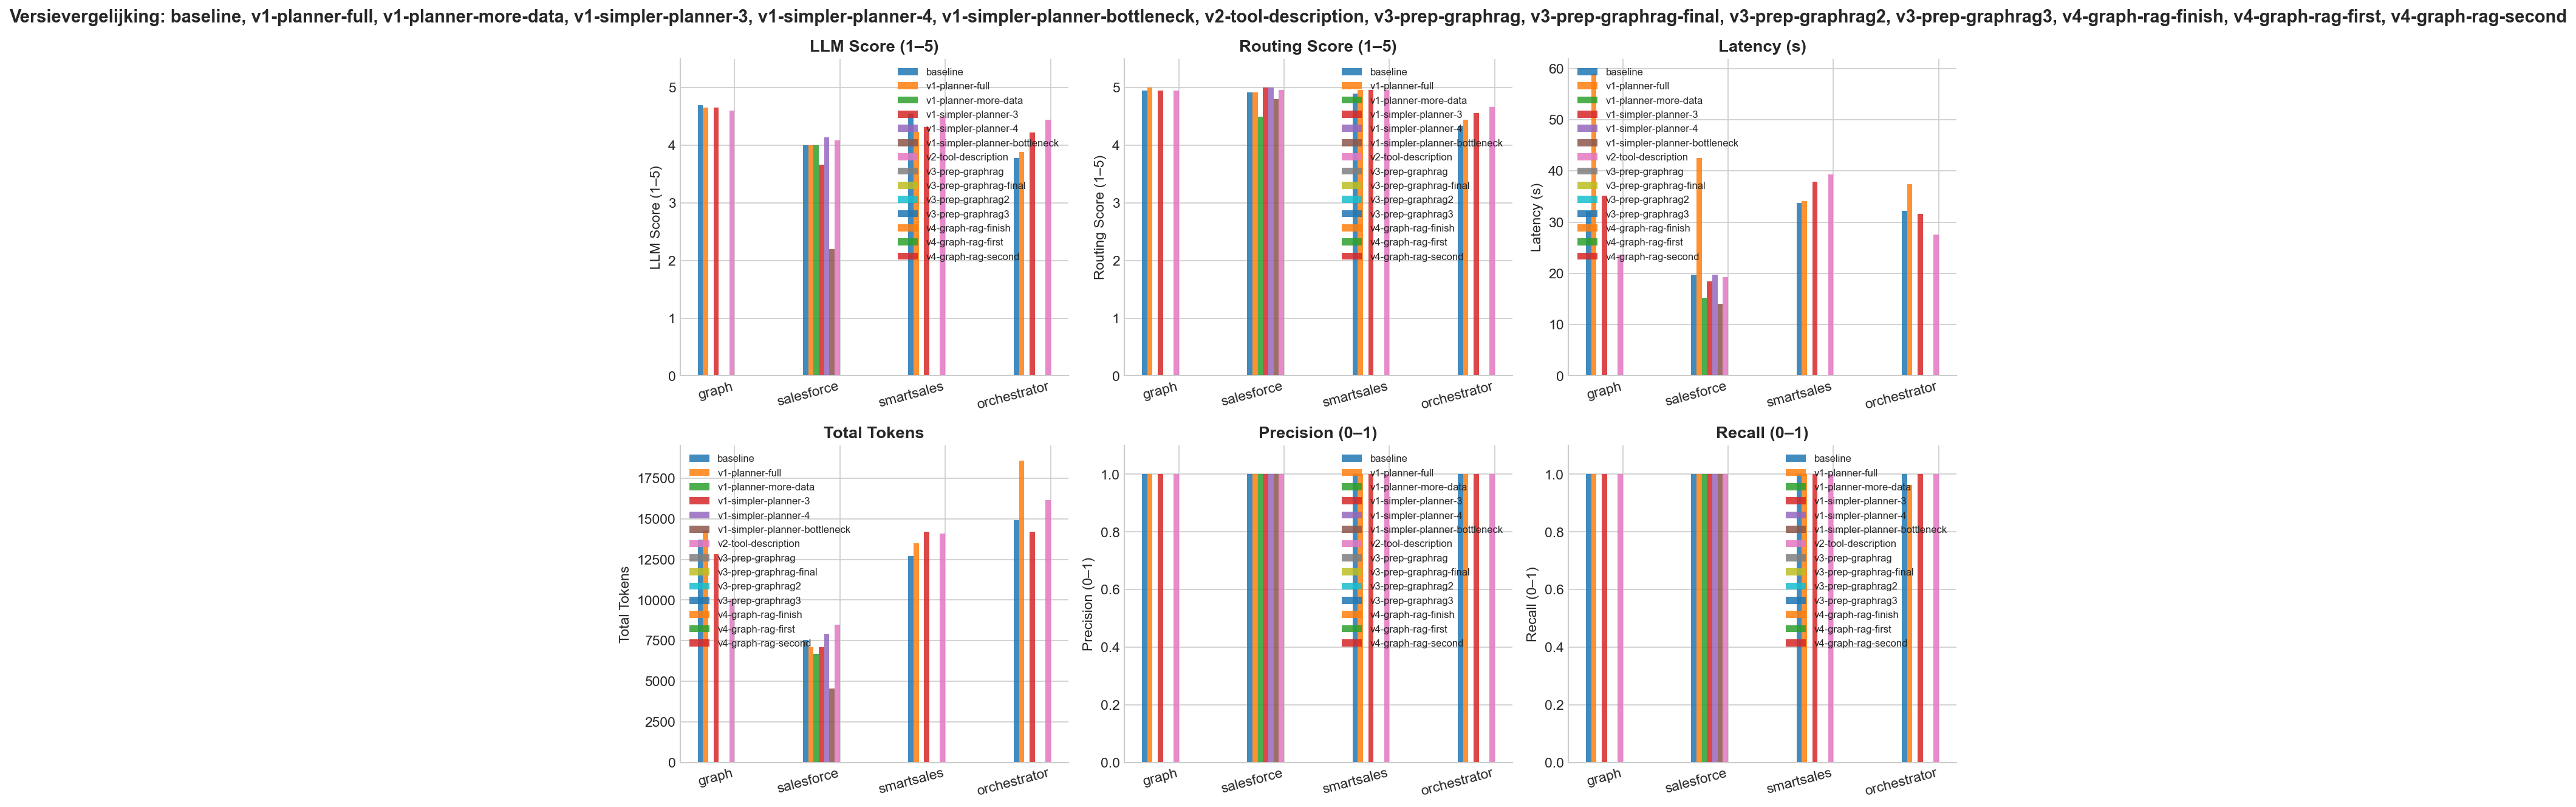


── Delta (v4-graph-rag-second − baseline) per agent group ──

llm_score:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

routing_score:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

latency_s:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN

total_tokens:
agent_group
graph          NaN
salesforce     NaN
smartsales     NaN
orchestrator   NaN


In [179]:
if N_VERSIONS < 2:
    print(f'Slechts 1 versie gevonden ({VERSIONS[0]}). Run mlflow_eval.py met --version v1 voor vergelijking.')
else:
    metrics_to_compare = [
        ('llm_score',         'LLM Score (1–5)',    (0, 5.5)),
        ('routing_score',     'Routing Score (1–5)', (0, 5.5)),
        ('latency_s',         'Latency (s)',          None),
        ('total_tokens',      'Total Tokens',         None),
        ('routing_precision', 'Precision (0–1)',      (0, 1.1)),
        ('routing_recall',    'Recall (0–1)',         (0, 1.1)),
    ]

    n_cols = 3
    n_rows = (len(metrics_to_compare) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4.5))
    axes = axes.flatten()

    for ax_idx, (metric, label, ylim) in enumerate(metrics_to_compare):
        ax    = axes[ax_idx]
        x     = np.arange(len(GROUP_ORDER))
        bar_w = 0.7 / N_VERSIONS
        for v_idx, version in enumerate(VERSIONS):
            vdf  = df[df['version'] == version]
            vals = [vdf[vdf['agent_group'] == g][metric].mean() for g in GROUP_ORDER]
            off  = (v_idx - (N_VERSIONS - 1) / 2) * bar_w
            ax.bar(x + off, vals, bar_w, label=version, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(GROUP_ORDER, rotation=15, ha='right')
        ax.set_ylabel(label)
        ax.set_title(label, fontweight='bold')
        if ylim:
            ax.set_ylim(*ylim)
        ax.legend(fontsize=8)

    for i in range(len(metrics_to_compare), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle(f'Versievergelijking: {", ".join(VERSIONS)}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('plot_version_comparison.png', bbox_inches='tight')
    plt.show()

    # Delta tabel
    print(f'\n── Delta ({VERSIONS[-1]} − {VERSIONS[0]}) per agent group ──')
    for metric in ['llm_score', 'routing_score', 'latency_s', 'total_tokens']:
        base  = df[df['version'] == VERSIONS[0]].groupby('agent_group')[metric].mean()
        comp  = df[df['version'] == VERSIONS[-1]].groupby('agent_group')[metric].mean()
        delta = (comp - base).reindex(GROUP_ORDER).round(3)
        print(f'\n{metric}:')
        print(delta.to_string())

## 11. Prompt coverage — welke prompts zijn al gerund?

In [180]:
import json as _json
import os as _os
from collections import Counter as _Counter

category = ["entity-centric1", "entity-centric2", "implicit-cross-system"]
# Zet op None om alle categorieën te checken
# category = None

# Pad naar prompts-bestand (afgeleid van TRACKING_URI)
_project_root = _os.path.dirname(TRACKING_URI.replace('sqlite:///', ''))
_prompts_file = _os.path.join(_project_root, 'eval', 'prompts', 'all_prompts.json')
if not _os.path.exists(_prompts_file):
    _prompts_file = 'eval/prompts/all_prompts.json'

with open(_prompts_file, encoding='utf-8') as _f:
    _all_prompts = _json.load(_f)

print(f'Prompts-bestand : {_prompts_file}')
print(f'Totaal in bestand: {len(_all_prompts)} prompts')

_fp = lambda text: text.strip()[:200]
_expected = {_fp(p['text']): p for p in _all_prompts}

if category:
    _expected = {k: v for k, v in _expected.items() if v.get('category') in category}
    print(f'Categorie filter: {category}')
print(f'Totaal verwacht : {len(_expected)} prompts')

# CHECK_VERSION = VERSIONS[0]  # aanpassen naar bijv. 'v1'
# CHECK_VERSION = VERSIONS[-1]
CHECK_VERSION =  "v4-graph-rag-finish" 
print(f'Versie checken  : {CHECK_VERSION}')

_vdf = df[df['version'] == CHECK_VERSION].copy()
_run_fps = set()
if 'query' in _vdf.columns:
    _run_fps = {_fp(str(q)) for q in _vdf['query'].dropna()}

_missing, _found = [], []
for _key, _p in _expected.items():
    _matched = any(_key.startswith(_r) or _r.startswith(_key) for _r in _run_fps)
    (_found if _matched else _missing).append(_p)

print(f'Gerund          : {len(_found)}')
print(f'Ontbrekend      : {len(_missing)}')
print()

if not _missing:
    print('Alle prompts zijn gerund!')
else:
    _miss_df = pd.DataFrame(_missing)[['category', 'difficulty', 'text']].copy()
    _miss_df['text'] = _miss_df['text'].str[:100]
    _miss_df = _miss_df.sort_values(['category', 'difficulty']).reset_index(drop=True)
    display(_miss_df)
    print()
    print('=== Commando per ontbrekende categorie ===')
    for _cat, _n in sorted(_Counter(p['category'] for p in _missing).items()):
        print(f'  python eval/mlflow_eval.py --version {CHECK_VERSION} --category {_cat}  # {_n} prompt(s)')

if 'query' in _vdf.columns:
    _dup_counts = _vdf['query'].dropna().apply(_fp).value_counts()
    _dupes = _dup_counts[_dup_counts > 1]
    print()
    if not _dupes.empty:
        print('=== Dubbele runs ===')
        for _key, _cnt in _dupes.items():
            _rows = _vdf[_vdf['query'].apply(lambda q: _fp(str(q))) == _key]
            _ids  = ', '.join(_rows['run_id'].str[:8].tolist())
            print(f'  [{_cnt}x] {_key[:80]}')
            print(f'         run_ids: {_ids}')
    else:
        print('Geen dubbele runs.')

Prompts-bestand : C:/Users/AALB/Desktop/mp/graph/graphxmaf\eval\prompts\all_prompts.json
Totaal in bestand: 122 prompts
Categorie filter: ['entity-centric1', 'entity-centric2', 'implicit-cross-system']
Totaal verwacht : 30 prompts
Versie checken  : v4-graph-rag-finish
Gerund          : 0
Ontbrekend      : 30



,category,difficulty,text
0,entity-centric1,hard,Tell me everything you know about supplier1.
1,entity-centric1,hard,Give me a full briefing on Colruyt.
2,entity-centric1,hard,What is the current status of our relationship with supplier1?
3,entity-centric1,hard,Who is Dorian and how do we work with him?
4,entity-centric1,hard,Give me a complete overview of everything related to Arne.
5,entity-centric1,hard,What do we know about GreenTech Solutions?
6,entity-centric1,hard,Prepare me for my next meeting. What do I have coming up and what do I know about the companies invo
7,entity-centric1,hard,Who are the most important companies we work with right now?
8,entity-centric1,hard,Is there anything I should follow up on today?
9,entity-centric1,hard,Give me a 360° view of the most recent email sender.



=== Commando per ontbrekende categorie ===
  python eval/mlflow_eval.py --version v4-graph-rag-finish --category entity-centric1  # 10 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-finish --category entity-centric2  # 10 prompt(s)
  python eval/mlflow_eval.py --version v4-graph-rag-finish --category implicit-cross-system  # 10 prompt(s)

Geen dubbele runs.


## 12. Dubbele runs vergelijken — welke bewaren / verwijderen?

In [181]:
# Plak hier de run_ids (8-char) uit cel 11 — alle duplicates bij elkaar
DUPLICATE_RUN_IDS = [
    "737f0dfa", "048c9a0a", "bf538265" 
]

# ── Match korte IDs naar volledige run_ids ────────────────────────────────────
_short_to_full = {rid[:8]: rid for rid in df['run_id']}
_full_ids = list({_short_to_full[s] for s in DUPLICATE_RUN_IDS if s in _short_to_full})

COLS = ['run_name', 'run_id', 'category', 'difficulty',
        'llm_score', 'routing_score', 'latency_s', 'total_tokens', 'success', 'llm_rationale']
_show_cols = [c for c in COLS if c in df.columns]

_dup_df = (
    df[df['run_id'].isin(_full_ids)]
    .sort_values(['category', 'difficulty', 'llm_score'], ascending=[True, True, False])
    [_show_cols]
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 100)
print(f'{len(_dup_df)} runs gevonden\n')

display(
    _dup_df.style
    .map(
        lambda v: 'background-color:#d1fae5' if isinstance(v, float) and v >= 4 else
                  ('background-color:#fee2e2' if isinstance(v, float) and v <= 2 else ''),
        subset=[c for c in ['llm_score', 'routing_score'] if c in _dup_df.columns],
    )
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .set_caption('Groen = score >= 4 | Rood = score <= 2')
)

# ── Automatisch beste run per prompt selecteren ───────────────────────────────
# Keuze: hoogste llm_score, bij gelijkspel laagste latency
_keep, _delete = [], []
if 'query' in df.columns:
    _dup_full = df[df['run_id'].isin(_full_ids)].copy()
    _dup_full['_fp'] = _dup_full['query'].fillna('').apply(lambda t: t.strip()[:200])

    print('=== Aanbevolen bewaren / verwijderen ===')
    for _fp_key, _grp in _dup_full.groupby('_fp'):
        _grp_sorted = _grp.sort_values(
            ['llm_score', 'routing_score', 'latency_s'],
            ascending=[False, False, True],
        )
        _best = _grp_sorted.iloc[0]
        _rest = _grp_sorted.iloc[1:]
        _keep.append(_best['run_id'])
        _delete.extend(_rest['run_id'].tolist())
        _label = (_best.get('run_name') or _best['run_id'][:8])
        print(f'  KEEP  {_label:<38} llm={_best["llm_score"]}/5  lat={_best["latency_s"]:.1f}s')
        for _, _r in _rest.iterrows():
            _rl = (_r.get('run_name') or _r['run_id'][:8])
            print(f'  DEL   {_rl:<38} llm={_r["llm_score"]}/5  lat={_r["latency_s"]:.1f}s')

    print(f'\n=== Verwijder {len(_delete)} run(s) — uncomment en run ===')
    print('# mlflow.set_tracking_uri(TRACKING_URI)')
    print('# for run_id in [')
    for _rid in _delete:
        _rname = (df[df['run_id'] == _rid]['run_name'].iloc[0]
                  if 'run_name' in df.columns else '')
        print(f'#     "{_rid}",  # {_rname}')
    print('# ]:')
    print('#     mlflow.delete_run(run_id)')

1 runs gevonden



,run_name,run_id,category,difficulty,llm_score,routing_score,latency_s,total_tokens,success,llm_rationale
0,tc00_leads_medium,737f0dfa002a4536ad9987cefcb3e048,leads,medium,4.000000,5.000000,13.061000,5192.000000,1.000000,"The response correctly lists leads from the Technology industry, providing the required details, but it does not include any leads from the Software industry, which was part of the request."


=== Aanbevolen bewaren / verwijderen ===
  KEEP  tc00_leads_medium                      llm=4.0/5  lat=13.1s

=== Verwijder 0 run(s) — uncomment en run ===
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
# ]:
#     mlflow.delete_run(run_id)


In [182]:
# mlflow.set_tracking_uri(TRACKING_URI)
# for run_id in [
#     "bf5382657a054cd8a3868c5c83752078",
#     "048c9a0a3fcc4a049cd8cd75b23b5bf0"

# ]:
#     mlflow.delete_run(run_id)

## 13. Versies verwijderen

In [183]:
# Beschikbare versies in de database
print("Beschikbare versies:")
for v in sorted(df["version"].dropna().unique()):
    n = (df["version"] == v).sum()
    print(f"  {v!r:40s}  ({n} runs)")

# ── Stel hier in welke versies je wilt verwijderen ────────────────────────────
VERSIONS_TO_DELETE = [
    "v1-simpler-planner",
    "v1-simpler-planner-new",
]

if not VERSIONS_TO_DELETE:
    print("Geen versies geselecteerd — vul VERSIONS_TO_DELETE in en run opnieuw.")
else:
    # Zoek alle child-runs voor de geselecteerde versies
    _child_ids = df[df["version"].isin(VERSIONS_TO_DELETE)]["run_id"].tolist()

    # Zoek de bijbehorende parent-runs
    _all_runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        output_format="pandas",
    )
    _parent_col = "tags.mlflow.parentRunId"
    _child_run_ids_set = set(_child_ids)

    # Parent run = geen parentRunId tag (of leeg)
    _is_parent = _all_runs.get(_parent_col, pd.Series("", index=_all_runs.index)).fillna("") == ""
    _parent_runs = _all_runs[_is_parent]
    _child_runs  = _all_runs[~_is_parent]

    # Behoud alleen parents waarvan ALLE children worden verwijderd
    _parent_ids_to_delete = []
    for _pid in _parent_runs["run_id"]:
        _kids = _child_runs[
            _child_runs.get(_parent_col, pd.Series("", index=_child_runs.index)).fillna("") == _pid
        ]["run_id"].tolist()
        if _kids and all(c in _child_run_ids_set for c in _kids):
            _parent_ids_to_delete.append(_pid)

    _total = len(_child_ids) + len(_parent_ids_to_delete)
    print(f"Te verwijderen: {len(_child_ids)} child-runs + {len(_parent_ids_to_delete)} parent-runs = {_total} runs")
    for _v in VERSIONS_TO_DELETE:
        _n = (df["version"] == _v).sum()
        print(f"  {_v!r}: {_n} child-runs")

    print("⚠️  Verwijderen is onomkeerbaar (soft-delete in MLflow).")
    print("Zet DRY_RUN = False om echt te verwijderen.")

    DRY_RUN = True # ← zet op False om echt te verwijderen

    mlflow.set_tracking_uri(TRACKING_URI)
    _deleted = 0
    for _rid in _child_ids + _parent_ids_to_delete:
        if not DRY_RUN:
            mlflow.delete_run(_rid)
        _deleted += 1

    if DRY_RUN:
        print(f"[DRY RUN] Zou {_deleted} runs verwijderen — zet DRY_RUN = False om te bevestigen.")
    else:
        print(f"Verwijderd: {_deleted} runs. Herlaad cel 3 (data laden) om df te verversen.")


Beschikbare versies:
  'baseline'                                (72 runs)
  'v1-planner-full'                         (76 runs)
  'v1-planner-more-data'                    (2 runs)
  'v1-simpler-planner-3'                    (75 runs)
  'v1-simpler-planner-4'                    (22 runs)
  'v1-simpler-planner-bottleneck'           (7 runs)
  'v2-tool-description'                     (77 runs)
  'v3-prep-graphrag'                        (24 runs)
  'v3-prep-graphrag-final'                  (38 runs)
  'v3-prep-graphrag2'                       (10 runs)
  'v3-prep-graphrag3'                       (10 runs)
  'v4-graph-rag-finish'                     (17 runs)
  'v4-graph-rag-first'                      (4 runs)
  'v4-graph-rag-second'                     (17 runs)
Te verwijderen: 0 child-runs + 0 parent-runs = 0 runs
  'v1-simpler-planner': 0 child-runs
  'v1-simpler-planner-new': 0 child-runs
⚠️  Verwijderen is onomkeerbaar (soft-delete in MLflow).
Zet DRY_RUN = False om echt te verwij

In [184]:
# # Neem alles van v3 BEHALVE salesforce, en vervang die door v4 salesforce
# BASE_VERSION    = 'v1-simpler-planner-3'
# OVERRIDE_VERSION = 'v1-simpler-planner-4'
# OVERRIDE_GROUP  = 'salesforce'

# df_base     = df[df['version'] == BASE_VERSION]
# df_override = df[(df['version'] == OVERRIDE_VERSION) & (df['agent_group'] == OVERRIDE_GROUP)]

# df_merged = pd.concat([
#     df_base[df_base['agent_group'] != OVERRIDE_GROUP],
#     df_override,
# ], ignore_index=True)

# # Label voor plots
# df_merged['version'] = 'v3+v4-sf'

# print(f'Base ({BASE_VERSION}) non-salesforce : {len(df_base[df_base["agent_group"] != OVERRIDE_GROUP])} runs')
# print(f'Override ({OVERRIDE_VERSION}) salesforce   : {len(df_override)} runs')
# print(f'Merged totaal                    : {len(df_merged)} runs')
# print()
# print(df_merged.groupby('agent_group')[['llm_score', 'routing_score']].mean().round(2).reindex(GROUP_ORDER))
